In [3]:
#붓꽃 데이터를 이용한 k-mean 군집화
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as pyplot
import numpy as numpy
import pandas as pd
%matplotlib inline

iris=load_iris()
# 더 편리한 데이터 핸들링을 위해 dataframe으로 변환
irisDF=pd.DataFrame(data=iris.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
irisDF.head(3)



,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [6]:
#붓꽃 데이터세트를 3개 그룹으로 군집화
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0)
kmeans.fit(irisDF)
#군집화 수행결과가 kmeans 객체 변수로 반환됨
print(kmeans.labels_)



[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [7]:
#실제 분류값과 군집화 결과 비교
irisDF['target']=iris.target
irisDF['cluster']=kmeans.labels_
iris_result=irisDF.groupby(['target','cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


In [8]:
from sklearn.decomposition import PCA
#세트 속성이 4개여서 PCA로 2개로 축소
pca=PCA(n_components=2)
pca_transformed=pca.fit_transform(iris.data)

# PCA 변환된 데이터의 첫 번째 열(PC1)을 irisDF의 'pca_x' 컬럼으로 추가
irisDF['pca_x']=pca_transformed[:,0]
# PCA 변환된 데이터의 두 번째 열(PC2)을 irisDF의 'pca_y' 컬럼으로 추가
irisDF['pca_y']=pca_transformed[:,1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,pca_x,pca_y,target,cluster
0,5.1,3.5,1.4,0.2,-2.684126,0.319397,0,1
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001,0,1
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949,0,1


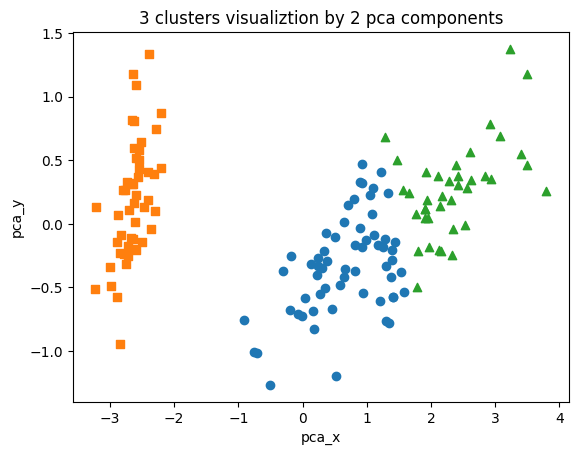

In [10]:
import matplotlib.pyplot as plt
#군집값이 0,1,2인 경우마다 별도의 인덱스로 추출
marker0_ind=irisDF[irisDF['cluster']==0].index
marker1_ind=irisDF[irisDF['cluster']==1].index
marker2_ind=irisDF[irisDF['cluster']==2].index

#군집값 0,1,2에 해당하는 인덱스로 각 군집 레벨의 pca_x, pca_y 값 추출, o,s,^로 마커 표시
#산점도 그리기
plt.scatter(x=irisDF.loc[marker0_ind,'pca_x'],y=irisDF.loc[marker0_ind,'pca_y'],marker='o')
plt.scatter(x=irisDF.loc[marker1_ind,'pca_x'],y=irisDF.loc[marker1_ind,'pca_y'],marker='s')
plt.scatter(x=irisDF.loc[marker2_ind,'pca_x'],y=irisDF.loc[marker2_ind,'pca_y'],marker='^')

plt.xlabel('pca_x')
plt.ylabel('pca_y')
plt.title('3 clusters visualiztion by 2 pca components')
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

# 데이터 생성
X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=0)
print(X.shape,y.shape)

# y target 값의 분포 확인
unique, counts = np.unique(y, return_counts=True)
print(unique,counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [2]:
import pandas as pd
# 데이터세트를 데이터프레임으로 변환
clusterDF=pd.DataFrame(X,columns=['ftr1','ftr2'])
clusterDF['target']=y
clusterDF.head(3)


,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


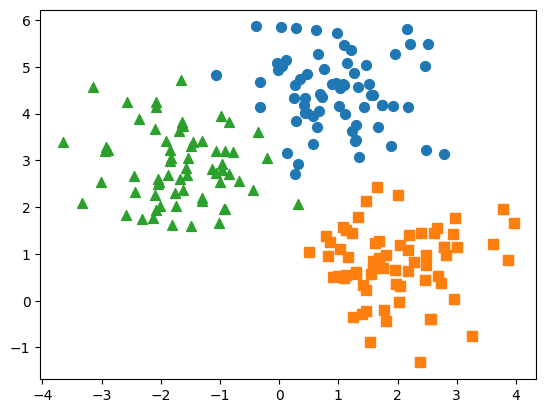

In [7]:
target_list=np.unique(y)
#각 타깃별 산점도의 마커 값
markers=['o','s','^','P','D','H','X']
#3개의 군집영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0,1,2]
#target=0, target=1,target=2로 scatter plot을 marker별로 생성

for target in target_list:
    target_cluster=clusterDF[clusterDF['target']==target]
    plt.scatter(x=target_cluster['ftr1'],y=target_cluster['ftr2'],marker=markers[target],s=50)

plt.show()


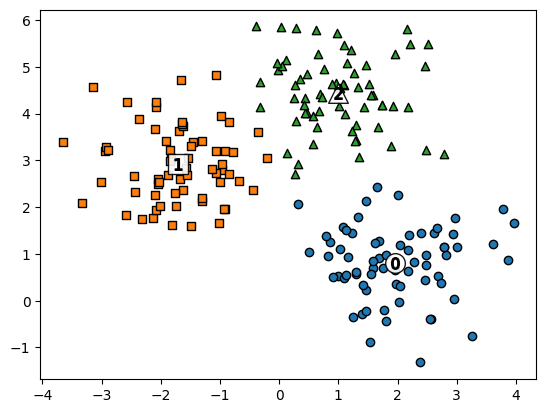

In [11]:
#KMeans 객체를 이용해 x 데이터를 k-means 클러스터링 수행
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=200,random_state=0)
cluster_labels=kmeans.fit_predict(X)
clusterDF['kmeans_label']=cluster_labels

#cluster_centers_는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers=kmeans.cluster_centers_
unique_labels=np.unique(cluster_labels)
markers=['o','s','^','P','D','H','x']

#군집된 Label 유형별로 Iteration 하면서 Marker별로 scatter plot 수행
for label in unique_labels:
    label_cluster=clusterDF[clusterDF['kmeans_label']==label]
    center_x_y=centers[label]
    plt.scatter(x=label_cluster['ftr1'],y=label_cluster['ftr2'],edgecolor='k',marker=markers[label])
    #군집별 중심위치 좌표 시각화
    plt.scatter(x=center_x_y[0],y=center_x_y[1],s=200,color='white',alpha=0.9,edgecolor='k',marker=markers[label])
    plt.scatter(x=center_x_y[0],y=center_x_y[1],s=70,color='k',edgecolor='k',marker='$%d$'%label)

plt.show()


In [12]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


In [5]:
#군집화 결과를 실루엣 분석으로 평가
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
#실루엣 분석 평가지표 값을 구하기 위한 api 추가
from sklearn.metrics import silhouette_samples,silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

#붓꽃 데이터 로드
iris=load_iris()
feature_name=['sepal_length','sepal_width','petal_length','petal_width']
irisDF=pd.DataFrame(data=iris.data,columns=feature_name)
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0).fit(irisDF)
irisDF['cluster']=kmeans.labels_

#iris의 모든 개별 데이터에 실루엣 계수값을 구함
score_samples=silhouette_samples(iris.data,irisDF['cluster'])
print('silhouette_samples() return shape:',score_samples.shape)

#irisDF에 실루엣 계수 칼럼 추가
irisDF['silhouette_coeff']=score_samples

#모든 데이터의 평균 실루엣 계수 계산
average_score=silhouette_score(iris.data,irisDF['cluster'])
print('\n붓꽃 데이터 세트 silhouette analysis score:{0:.3f}'.format(average_score))
irisDF.head(3)

silhouette_samples() return shape: (150,)

붓꽃 데이터 세트 silhouette analysis score:0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [6]:
#군집별 평균 실루엣 계수 계산
irisDF.groupby('cluster')['silhouette_coeff'].mean()

cluster
0    0.422323
1    0.797604
2    0.436842
Name: silhouette_coeff, dtype: float64